<style>
  /* Hate Speech — notebook theme */
  .nb-hero {
    background: linear-gradient(135deg, #0f172a 0%, #312e81 40%, #5b21b6 100%);
    color: #f1f5f9;
    padding: 1.75rem 1.5rem 1.5rem;
    border-radius: 14px;
    margin: 0 0 1.25rem;
    box-shadow: 0 12px 40px rgba(15, 23, 42, 0.35);
    font-family: ui-sans-serif, "Segoe UI", system-ui, sans-serif;
  }
  .nb-hero h1 { margin: 0 0 0.5rem; font-size: 1.75rem; font-weight: 700; letter-spacing: -0.02em; }
  .nb-hero p { margin: 0; opacity: 0.92; font-size: 0.98rem; line-height: 1.5; }
  .nb-hero .nb-sub { margin-top: 1rem; display: flex; flex-wrap: wrap; gap: 0.4rem; }
  .nb-pill { background: rgba(255,255,255,0.12); border: 1px solid rgba(255,255,255,0.2); border-radius: 999px; padding: 0.2rem 0.75rem; font-size: 0.8rem; }
  .nb-section { font-family: ui-sans-serif, "Segoe UI", system-ui, sans-serif; color: #0f172a; margin: 0 0 1rem; }
  .nb-section h2 { margin: 0 0 0.75rem; font-size: 1.2rem; font-weight: 700; color: #1e1b4b; display: flex; align-items: center; gap: 0.5rem; }
  .nb-kicker { display: inline-block; background: linear-gradient(135deg, #e0e7ff, #ede9fe); color: #4338ca; font-size: 0.7rem; font-weight: 700; letter-spacing: 0.06em; text-transform: uppercase; padding: 0.2rem 0.55rem; border-radius: 6px; }
  .nb-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 1rem 1.1rem; margin: 0.5rem 0; }
  .nb-card ul { margin: 0.4rem 0 0; padding-left: 1.2rem; }
  .nb-card li { margin: 0.25rem 0; }
  .nb-goals { color: #475569; font-size: 0.92rem; line-height: 1.55; margin: 0.35rem 0 0.75rem; }
  .nb-callout { border-left: 4px solid #6366f1; background: #eef2ff; padding: 0.65rem 0.9rem; border-radius: 0 8px 8px 0; font-size: 0.92rem; color: #3730a3; margin: 0.5rem 0; font-style: italic; }
  .nb-grid-2 { display: grid; grid-template-columns: 1fr 1fr; gap: 0.75rem; margin-top: 0.5rem; }
  @media (max-width: 700px) { .nb-grid-2 { grid-template-columns: 1fr; } }
  .nb-compare h4 { margin: 0 0 0.35rem; font-size: 0.85rem; color: #334155; }
  .nb-compare p, .nb-compare li { font-size: 0.86rem; color: #64748b; }
  .nb-compare .ok { color: #059669; }
  .nb-compare .warn { color: #d97706; }
  .nb-embed-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 0.6rem; margin-top: 0.5rem; }
  .nb-embed { background: #fff; border: 1px solid #e2e8f0; border-radius: 8px; padding: 0.75rem; font-size: 0.85rem; }
  .nb-embed h4 { margin: 0 0 0.4rem; font-size: 0.88rem; color: #0f172a; }
  .nb-embed p { margin: 0.15rem 0; color: #64748b; line-height: 1.4; }
  .nb-embed p:first-of-type::before { content: "✓ "; color: #6366f1; font-weight: bold; }
  .nb-divider { text-align: center; color: #94a3b8; font-size: 0.8rem; margin: 1.25rem 0; letter-spacing: 0.2em; }
  .nb-data { background: linear-gradient(90deg, #f0fdf4, #ecfeff); border: 1px solid #a7f3d0; border-radius: 10px; padding: 1rem 1.1rem; font-family: ui-sans-serif, system-ui, sans-serif; }
  .nb-data h2 { margin: 0; font-size: 1.1rem; color: #14532d; }
  .nb-data p { margin: 0.4rem 0 0; color: #166534; font-size: 0.9rem; }
  .nb-foot { text-align: center; color: #94a3b8; font-size: 0.8rem; margin: 1.5rem 0 0.5rem; }
</style>

<div class="nb-hero">
  <h1>Pipeline de prétraitement NLP</h1>
  <div class="nb-sub">
    <span class="nb-pill">Nettoyage</span>
    <span class="nb-pill">Tokenization</span>
    <span class="nb-pill">Stopwords</span>
    <span class="nb-pill">Lemmatization</span>
    <span class="nb-pill">Data</span>
  </div>
</div>

In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn nltk gensim tqdm transformers torch wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install emoji num2words

In [3]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/ilham/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/ilham/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/ilham/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ilham/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
# ===============================
# Core Libraries
# ===============================

import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Text Processing
# ===============================

import re
import emoji
from num2words import num2words

# ===============================
# NLP (NLTK)
# ===============================

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ===============================
# Machine Learning
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ===============================
# Vectorization Methods
# Order: Word2Vec → FastText → GloVe
# ===============================

from gensim.models import Word2Vec
from gensim.models import FastText

# GloVe uses numpy (no special import needed)

# ===============================
# BERT (Transformer Models)
# ===============================

import torch
from transformers import BertTokenizer

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv("HateSpeechData.csv")

In [6]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df.describe()

,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,3.243473,0.280515,2.413711,0.549247,1.110277
std,0.883060,0.631851,1.399459,1.113299,0.462089
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000,0.000000,1.000000
50%,3.000000,0.000000,3.000000,0.000000,1.000000
75%,3.000000,0.000000,3.000000,0.000000,1.000000
max,9.000000,7.000000,9.000000,9.000000,2.000000


In [9]:
df["class"].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

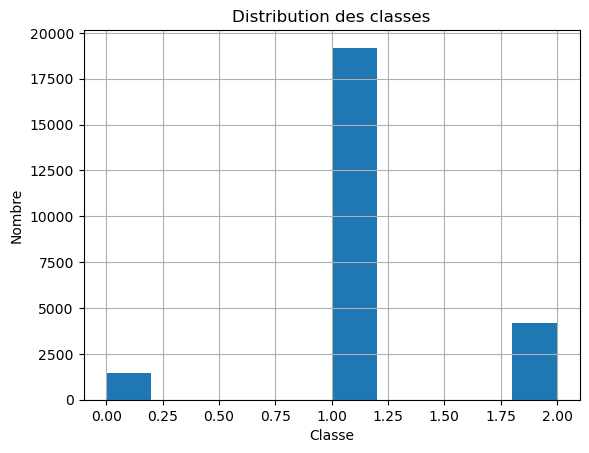

In [10]:
df["class"].hist()
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre")
plt.show()

 # 1. text cleaning

In [11]:
def clean_text(text, lang="en"):
    if not isinstance(text, str):
        text = str(text)
    if not text:
        return text

    # Emojis -> :alias: (before removing punctuation)
    text = emoji.demojize(text)
    text = text.lower()

    # Digits -> spelled-out words (e.g. 42 -> forty-two in English)
    def _digits_to_words(m):
        try:
            return num2words(int(m.group(0)), lang=lang)
        except (ValueError, OverflowError, NotImplementedError):
            return m.group(0)

    text = re.sub(r"\d+", _digits_to_words, text)
    # "forty-two" uses '-', which is not a word char — turn it into a space
    text = text.replace("-", " ")
    text = re.sub(r"[^\w\s]", "", text) # Removes punctuation and symbols
    text = re.sub(r"\s+", " ", text).strip() # Collapses multiple spaces, tabs, newlines into a single space
    return text

# 2. tokenization

In [12]:
def tokenize_text(text):
    tokens = text.split()
    return tokens

In [13]:
clean_comment = clean_text("You are STUPID!!! 😡 123")
tokenize_text(clean_comment)

['you',
 'are',
 'stupid',
 'enraged_face',
 'one',
 'hundred',
 'and',
 'twenty',
 'three']

# 3. stopword

In [14]:
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [15]:
def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

In [16]:
tokens = ["you", "are", "a", "stupid", "person"]
remove_stopwords(tokens)

['stupid', 'person']

# 4. lemmatization

In [17]:
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /home/ilham/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ilham/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [18]:
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(w, pos='v') for w in tokens]

In [19]:
tokens = ["running", "hated", "better"]
lemmatize_text(tokens)

['run', 'hat', 'better']

In [20]:
def full_preprocess(text):
    if pd.isna(text):
        return ""
    
    text = clean_text(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_text(tokens)
    
    return " ".join(tokens)

In [21]:
df["cleaned_text"] = df["tweet"].apply(full_preprocess)

In [22]:
pd.set_option('display.max_colwidth', None)
df[["tweet", "cleaned_text"]].head(5)

,tweet,cleaned_text
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,rt mayasolovely woman shouldnt complain clean house amp man always take trash
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,rt mleewseventeen boy dats coldtyga dwn bad cuffin dat hoe onest place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,rt urkindofbrand dawg rt eightysbabyfourlife ever fuck bitch start cry confuse shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,rt c_g_anderson viva_based look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,rt shenikaroberts shit hear might true might faker bitch tell ya fifty seven thousand three hundred sixty one


# 5. vectorization (Embedding)

## word2vect

In [23]:
sentences = [
    row.split()
    for row in df["cleaned_text"].astype(str)
    if row.strip()
]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2, 
    epochs=5,
)


In [24]:
word = "trash"
if word in model.wv:
    vector = model.wv[word]
else:
    print(word, "not in vocabulary (try min_count=1 or another word)")

## FastText

In [25]:
sentences = [
    row.split()
    for row in df["cleaned_text"].astype(str)
    if row.strip()
]
fasttext_model = FastText(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=5
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [26]:
word = "trash"
print("FastText:", fasttext_model.wv[word][:5])

FastText: [-0.0975933   0.08261957 -0.02894511  0.02123291  0.6460176 ]


## GloVe

In [27]:
# ===============================
# GloVe — Load Pretrained Vectors
# ===============================

glove_path = "glove.6B.100d.txt"

glove_embeddings = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_embeddings[word] = vector

print("Loaded", len(glove_embeddings), "GloVe word vectors")

Loaded 400000 GloVe word vectors


In [28]:
# ===============================
# Test Word Vector
# ===============================

word = "trash"

if word in glove_embeddings:
    vector = glove_embeddings[word]
    print("GloVe:", vector[:5])  # show first 5 numbers
else:
    print(word, "not in GloVe vocabulary")

GloVe: [-0.23076  0.4707   0.76068 -1.5495   0.2006 ]


In [30]:
# ===============================
# Convert Sentences to GloVe Vectors
# ===============================

def sentence_to_glove_vector(sentence, embeddings, dim=100):
    words = sentence.split()
    
    vectors = []
    
    for word in words:
        if word in embeddings:
            vectors.append(embeddings[word])
    
    if len(vectors) == 0:
        return np.zeros(dim)
    
    return np.mean(vectors, axis=0)


glove_sentence_vectors = np.array([
    sentence_to_glove_vector(text, glove_embeddings)
    for text in df["cleaned_text"]
])

print("GloVe sentence vectors shape:", glove_sentence_vectors.shape)

GloVe sentence vectors shape: (24783, 100)
